In [1]:
import logging

import stac_gti_xarray

logging.basicConfig(level="INFO")

In [2]:
da = await stac_gti_xarray.open(
    href="https://earth-search.aws.element84.com/v1",
    collections=["sentinel-2-c1-l2a"],
    datetime="2025-06-01/2025-06-05",
    bbox=(-150000, 2500000, 600000, 3000000),
    crs="epsg:5070",
    resolution=10,
    bands=["red", "green", "blue"],  # optional; auto-discovered if omitted
    chunks={"x": 2048, "y": 2048},
    sort_by="eo:cloud_cover",  # optional; controls mosaic priority
)
da

INFO:stac_gti_xarray._core:querying STAC at https://earth-search.aws.element84.com/v1 with {'collections': ['sentinel-2-c1-l2a'], 'datetime': '2025-06-01T00:00:00Z/2025-06-05T23:59:59Z', 'bbox': (-98.05698994928109, 45.27048149530271, -87.79123172531241, 50.019856668830336), 'compression': None, 'limit': 100, 'sortby': 'properties.eo:cloud_cover'}
IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

INFO:stac_io.store:get_format; href=Path { raw: "tmp/tmpvml3zizn/items.parquet" } format=Geoparquet(WriterOptions { compression: Some(ZSTD(ZstdLevel(15))), max_row_group_row_count: 150000 })
INFO:stac_gti_xarray._core:discovered 19 raster bands: ['red', 'green', 'blue', 'visual', 'nir', 'swir22', 'rededge2', 'rededge3', 'rededg

<xarray.DataArray (time: 5, band: 3, y: 50000, x: 75000)> Size: 112GB
dask.array<concatenate, shape=(5, 3, 50000, 75000), dtype=uint16, chunksize=(1, 1, 2048, 2048), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[us] 40B 2025-06-01 2025-06-02 ... 2025-06-05
  * band         (band) object 24B 'red' 'green' 'blue'
  * y            (y) float64 400kB 3e+06 3e+06 3e+06 ... 2.5e+06 2.5e+06 2.5e+06
  * x            (x) float64 600kB -1.5e+05 -1.5e+05 -1.5e+05 ... 6e+05 6e+05
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    0
    scale_factor:  0.0001
    add_offset:    -0.1
    long_name:     B04

In [3]:
test = da.isel(x=slice(30000, 31000), y=slice(30000, 31000))
test

<xarray.DataArray (time: 5, band: 3, y: 1000, x: 1000)> Size: 30MB
dask.array<getitem, shape=(5, 3, 1000, 1000), dtype=uint16, chunksize=(1, 1, 720, 720), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[us] 40B 2025-06-01 2025-06-02 ... 2025-06-05
  * band         (band) object 24B 'red' 'green' 'blue'
  * y            (y) float64 8kB 2.7e+06 2.7e+06 2.7e+06 ... 2.69e+06 2.69e+06
  * x            (x) float64 8kB 1.5e+05 1.5e+05 1.5e+05 ... 1.6e+05 1.6e+05
    spatial_ref  int64 8B 0
Attributes:
    _FillValue:    0
    scale_factor:  0.0001
    add_offset:    -0.1
    long_name:     B04

DEBUG:rasterio._io:Output nodata value read from file: 0.0
DEBUG:rasterio._io:Output nodata values: [0.0]
DEBUG:rasterio._io:all_valid: False
DEBUG:rasterio._io:mask_flags: ([<MaskFlags.nodata: 8>],)
DEBUG:rasterio._io:Jump straight to _read()
DEBUG:rasterio._io:Window: Window(col_off=30720, row_off=30720, width=2048, height=2048)
DEBUG:rasterio._io:IO window xoff=30720.0 yoff=30720.0 width=2048.0 height=2048.0
DEBUG:rasterio._io:Output nodata value read from file: 0.0
DEBUG:rasterio._io:Output nodata values: [0.0]
DEBUG:rasterio._io:all_valid: False
DEBUG:rasterio._io:mask_flags: ([<MaskFlags.nodata: 8>],)
DEBUG:rasterio._io:Jump straight to _read()
DEBUG:rasterio._io:Window: Window(col_off=28672, row_off=30720, width=2048, height=2048)
DEBUG:rasterio._io:IO window xoff=28672.0 yoff=30720.0 width=2048.0 height=2048.0
DEBUG:rasterio._io:Output nodata value read from file: 0.0
DEBUG:rasterio._io:Output nodata values: [0.0]
DEBUG:rasterio._io:all_valid: False
DEBUG:rasterio._io:mask_flag

CPU times: user 1.92 s, sys: 1.33 s, total: 3.25 s
Wall time: 3.19 s


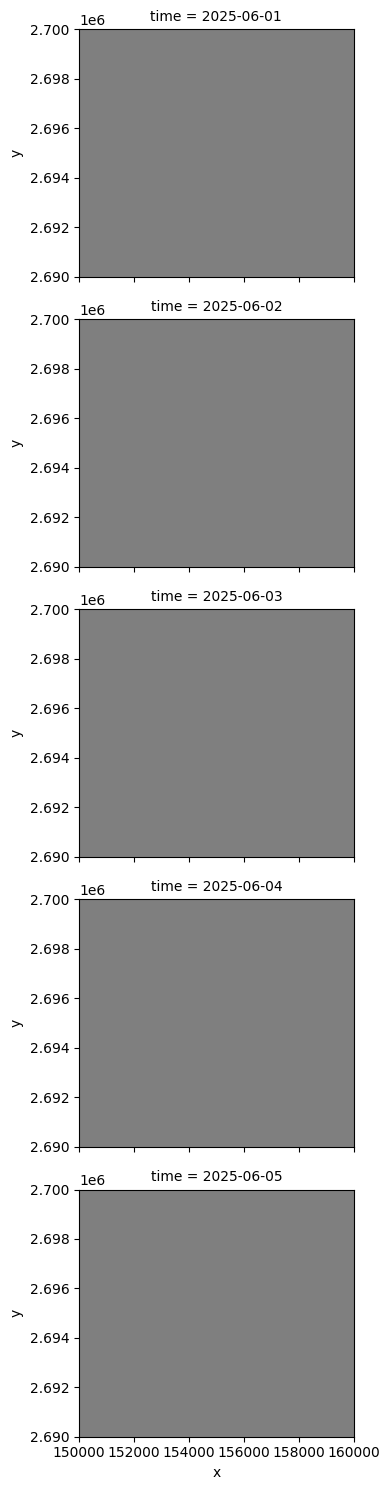

In [4]:
%%time
test.plot.imshow(rgb="band", vmin=0, vmax=4000, row="time")